# Linux Memory

Connect Linux memory accounting and virtual-memory behavior to controlled process activity.

## Objectives

Interpret selected `/proc` memory metrics and distinguish virtual, resident, cached, and available memory.

## Background

Linux uses virtual memory, demand paging, and filesystem caches, so allocated memory and physically resident memory are not equivalent.

## Prediction

Reserving an anonymous virtual-memory mapping without accessing its pages should substantially increase the process virtual address-space size while causing little change in resident memory or system-wide available memory. Touching one byte in each page should trigger demand allocation, increasing process RSS, anonymous resident memory, and private dirty memory while reducing MemAvailable. Releasing the mapping should reduce the process counters and allow available memory to recover. Reading a file-backed mapping should instead increase file-backed resident memory and filesystem cache, demonstrating that cached memory remains reclaimable and is not equivalent to unavailable memory.

## Environment

In [1]:
import os
import platform
import socket
import sys
from pathlib import Path

repository_root = next(
    (
        path
        for path in (Path.cwd(), *Path.cwd().parents)
        if (path / "pyproject.toml").is_file()
    ),
    None,
)
if repository_root is None:
    raise RuntimeError("Run this notebook from within the repository")
if str(repository_root) not in sys.path:
    sys.path.insert(0, str(repository_root))

print(f"Python: {sys.version}")
print(f"Platform: {platform.platform()}")
print(f"Hostname: {socket.gethostname()}")
print(f"Working directory: {os.getcwd()}")

Python: 3.14.3 (main, Feb 12 2026, 00:45:04) [Clang 21.1.4 ]
Platform: Linux-6.17.0-1026-nvidia-aarch64-with-glibc2.39
Hostname: spark-0240
Working directory: /home/coert/workspace/dgx-spark-lab/experiments/00-foundations


## Experiment

In [3]:
from common.cpu import read_proc_file

# Baseline read only; allocation steps remain intentionally unimplemented.
print(read_proc_file("meminfo")[:1000])

MemTotal:       127600588 kB
MemFree:        103230220 kB
MemAvailable:   119547392 kB
Buffers:          429228 kB
Cached:         16529672 kB
SwapCached:        45788 kB
Active:          5043168 kB
Inactive:       15214916 kB
Active(anon):    3171380 kB
Inactive(anon):   150656 kB
Active(file):    1871788 kB
Inactive(file): 15064260 kB
Unevictable:       39348 kB
Mlocked:           24948 kB
SwapTotal:      16777212 kB
SwapFree:       16287412 kB
Zswap:                 0 kB
Zswapped:              0 kB
Dirty:              1252 kB
Writeback:             0 kB
AnonPages:       3326196 kB
Mapped:           671052 kB
Shmem:             16796 kB
KReclaimable:     522568 kB
Slab:            1103988 kB
SReclaimable:     522568 kB
SUnreclaim:       581420 kB
KernelStack:       21264 kB
ShadowCallStack:    5396 kB
PageTables:        64760 kB
SecPageTables:     17900 kB
NFS_Unstable:          0 kB
Bounce:                0 kB
WritebackTmp:          0 kB
CommitLimit:    80577504 kB
Committed_AS:   1

In [4]:
from __future__ import annotations

import re
from pathlib import Path


MEMORY_VALUE_PATTERN = re.compile(
    r"^(?P<key>[^:]+):\s+(?P<value>\d+)(?:\s+(?P<unit>\w+))?$"
)


def parse_memory_file(text: str) -> dict[str, int]:
    """Parse Linux key/value memory files into byte counts."""
    values: dict[str, int] = {}

    for line in text.splitlines():
        match = MEMORY_VALUE_PATTERN.match(line)
        if match is None:
            continue

        key = match.group("key")
        value = int(match.group("value"))
        unit = match.group("unit")

        if unit == "kB":
            value *= 1024
        elif unit not in {None, "B"}:
            raise ValueError(f"Unsupported unit {unit!r} for {key!r}")

        values[key] = value

    return values


def read_key_value_file(path: Path) -> dict[str, int]:
    return parse_memory_file(path.read_text())


def format_mib(value: int | None) -> float | None:
    if value is None:
        return None
    return value / 1024**2

In [5]:
SYSTEM_FIELDS = [
    "MemTotal",
    "MemFree",
    "MemAvailable",
    "Buffers",
    "Cached",
    "SReclaimable",
    "Shmem",
    "AnonPages",
    "Mapped",
    "PageTables",
    "SwapTotal",
    "SwapFree",
]

PROCESS_STATUS_FIELDS = [
    "VmSize",
    "VmRSS",
    "RssAnon",
    "RssFile",
    "RssShmem",
    "VmSwap",
]

PROCESS_SMAPS_FIELDS = [
    "Rss",
    "Pss",
    "Anonymous",
    "LazyFree",
    "Private_Clean",
    "Private_Dirty",
    "Shared_Clean",
    "Shared_Dirty",
    "Swap",
]

In [ ]:
import os
import time

import pandas as pd


def collect_memory_snapshot(
    pid: int,
    stage: str,
) -> dict[str, object]:
    """Collect selected system-wide and per-process memory counters."""
    meminfo = read_key_value_file(Path("/proc/meminfo"))
    status = read_key_value_file(Path(f"/proc/{pid}/status"))
    smaps = read_key_value_file(Path(f"/proc/{pid}/smaps_rollup"))

    snapshot: dict[str, object] = {
        "stage": stage,
        "timestamp": time.time(),
        "pid": pid,
    }

    for field in SYSTEM_FIELDS:
        snapshot[f"system_{field}_mib"] = format_mib(meminfo.get(field))

    for field in PROCESS_STATUS_FIELDS:
        snapshot[f"process_{field}_mib"] = format_mib(status.get(field))

    for field in PROCESS_SMAPS_FIELDS:
        snapshot[f"smaps_{field}_mib"] = format_mib(smaps.get(field))

    return snapshot


notebook_snapshot = collect_memory_snapshot(
    os.getpid(),
    "notebook baseline",
)

pd.DataFrame([notebook_snapshot]).T

,0
stage,notebook baseline
timestamp,1785361040.054829
pid,192074
system_MemTotal_mib,124609.949219
system_MemFree_mib,100559.480469
system_MemAvailable_mib,116494.398438
system_Buffers_mib,419.203125
system_Cached_mib,16142.269531
system_SReclaimable_mib,510.445312
system_Shmem_mib,16.402344


In [ ]:
import multiprocessing as mp
import mmap
from multiprocessing.connection import Connection


MAPPING_SIZE = 1 * 1024**3
TOUCH_INCREMENT = 128 * 1024**2
PAGE_SIZE = os.sysconf("SC_PAGE_SIZE")

assert MAPPING_SIZE % PAGE_SIZE == 0
assert TOUCH_INCREMENT % PAGE_SIZE == 0


def anonymous_memory_worker(
    connection: Connection,
    mapping_size: int,
    page_size: int,
) -> None:
    """Reserve, touch and release an anonymous mapping on command."""
    mapping: mmap.mmap | None = None
    touched_bytes = 0

    try:
        connection.send(
            {
                "event": "ready",
                "pid": os.getpid(),
                "page_size": page_size,
            }
        )

        while True:
            command = connection.recv()
            action = command["action"]

            if action == "reserve":
                if mapping is not None:
                    raise RuntimeError("Mapping already exists")

                mapping = mmap.mmap(
                    -1,
                    mapping_size,
                    flags=mmap.MAP_PRIVATE | mmap.MAP_ANONYMOUS,
                    prot=mmap.PROT_READ | mmap.PROT_WRITE,
                )
                touched_bytes = 0

                connection.send(
                    {
                        "event": "reserved",
                        "touched_bytes": touched_bytes,
                    }
                )

            elif action == "touch":
                if mapping is None:
                    raise RuntimeError("No mapping exists")

                requested_bytes = int(command["bytes"])
                new_limit = min(
                    mapping_size,
                    touched_bytes + requested_bytes,
                )

                for offset in range(
                    touched_bytes,
                    new_limit,
                    page_size,
                ):
                    mapping[offset] = 1

                touched_bytes = new_limit

                connection.send(
                    {
                        "event": "touched",
                        "touched_bytes": touched_bytes,
                    }
                )

            elif action == "release":
                if mapping is not None:
                    mapping.close()
                    mapping = None

                touched_bytes = 0
                connection.send({"event": "released"})

            elif action == "exit":
                if mapping is not None:
                    mapping.close()

                connection.send({"event": "exiting"})
                break

            else:
                raise ValueError(f"Unknown action: {action!r}")

    finally:
        connection.close()

In [9]:
for connection_name in [
    "parent_connection",
    "child_connection",
]:
    connection = globals().get(connection_name)

    if connection is not None:
        try:
            connection.close()
        except (OSError, ValueError):
            pass

failed_process = globals().get("memory_process")

if failed_process is not None:
    try:
        failed_process.join(timeout=1)
    except (AssertionError, ValueError):
        pass

In [11]:
# Jupyter-defined worker functions are not importable by the
# spawn/forkserver start methods. On Linux, use fork explicitly.
memory_context = mp.get_context("fork")

parent_connection, child_connection = memory_context.Pipe()

memory_process = memory_context.Process(
    target=anonymous_memory_worker,
    args=(
        child_connection,
        MAPPING_SIZE,
        PAGE_SIZE,
    ),
)

memory_process.start()
child_connection.close()

try:
    ready_message = parent_connection.recv()
except EOFError as error:
    memory_process.join(timeout=1)

    raise RuntimeError(
        "The anonymous-memory child exited before initialization. "
        f"Exit code: {memory_process.exitcode}"
    ) from error

assert ready_message["event"] == "ready"

child_pid = int(ready_message["pid"])

print(f"Multiprocessing start method: {memory_context.get_start_method()}")
print(f"Child PID: {child_pid}")
print(f"Page size: {ready_message['page_size']} bytes")
print(f"Mapping size: {MAPPING_SIZE / 1024**3:.1f} GiB")

anonymous_snapshots: list[dict[str, object]] = []

anonymous_snapshots.append(
    collect_memory_snapshot(
        child_pid,
        "baseline",
    )
)

Multiprocessing start method: fork
Child PID: 193330
Page size: 4096 bytes
Mapping size: 1.0 GiB


In [12]:
parent_connection.send({"action": "reserve"})

reserve_message = parent_connection.recv()
assert reserve_message["event"] == "reserved"

time.sleep(0.2)

anonymous_snapshots.append(
    collect_memory_snapshot(
        child_pid,
        "reserved 1 GiB",
    )
)

pd.DataFrame(anonymous_snapshots)[
    [
        "stage",
        "process_VmSize_mib",
        "process_VmRSS_mib",
        "process_RssAnon_mib",
        "smaps_Anonymous_mib",
        "smaps_Private_Dirty_mib",
        "system_MemAvailable_mib",
    ]
]

,stage,process_VmSize_mib,process_VmRSS_mib,process_RssAnon_mib,smaps_Anonymous_mib,smaps_Private_Dirty_mib,system_MemAvailable_mib
0,baseline,2634.421875,119.476562,114.324219,114.324219,4.027344,116623.585938
1,reserved 1 GiB,3658.421875,119.664062,114.324219,114.324219,7.667969,116836.390625


In [13]:
for touched_total in range(
    TOUCH_INCREMENT,
    MAPPING_SIZE + TOUCH_INCREMENT,
    TOUCH_INCREMENT,
):
    parent_connection.send(
        {
            "action": "touch",
            "bytes": TOUCH_INCREMENT,
        }
    )

    touch_message = parent_connection.recv()
    assert touch_message["event"] == "touched"

    actual_touched = int(touch_message["touched_bytes"])
    time.sleep(0.2)

    anonymous_snapshots.append(
        collect_memory_snapshot(
            child_pid,
            f"touched {actual_touched / 1024**2:.0f} MiB",
        )
    )

In [14]:
anonymous_results = pd.DataFrame(anonymous_snapshots)

anonymous_results[
    [
        "stage",
        "process_VmSize_mib",
        "process_VmRSS_mib",
        "process_RssAnon_mib",
        "smaps_Anonymous_mib",
        "smaps_Private_Dirty_mib",
        "system_MemAvailable_mib",
        "system_AnonPages_mib",
        "system_PageTables_mib",
    ]
]

,stage,process_VmSize_mib,process_VmRSS_mib,process_RssAnon_mib,smaps_Anonymous_mib,smaps_Private_Dirty_mib,system_MemAvailable_mib,system_AnonPages_mib,system_PageTables_mib
0,baseline,2634.421875,119.476562,114.324219,114.324219,4.027344,116623.585938,3354.859375,65.585938
1,reserved 1 GiB,3658.421875,119.664062,114.324219,114.324219,7.667969,116836.390625,3158.460938,61.257812
2,touched 128 MiB,3658.421875,247.664062,242.324219,242.324219,141.250000,116453.554688,3517.335938,66.140625
3,touched 256 MiB,3658.421875,375.664062,370.324219,370.324219,269.250000,116327.554688,3645.335938,66.390625
4,touched 384 MiB,3658.421875,503.664062,498.324219,498.324219,397.250000,116201.554688,3773.335938,66.640625
5,touched 512 MiB,3658.421875,631.664062,626.324219,626.324219,525.253906,116075.554688,3901.335938,66.890625
6,touched 640 MiB,3658.421875,759.664062,754.324219,754.324219,653.261719,115941.679688,4029.335938,67.140625
7,touched 768 MiB,3658.421875,887.664062,882.324219,882.324219,781.269531,115815.679688,4157.335938,67.390625
8,touched 896 MiB,3658.421875,1015.664062,1010.324219,1010.324219,909.273438,115689.679688,4285.019531,67.453125
9,touched 1024 MiB,3658.421875,1143.664062,1138.324219,1138.324219,1037.285156,115563.679688,4413.027344,67.703125


In [ ]:
baseline = anonymous_results.iloc[0]

anonymous_deltas = anonymous_results.copy()

DELTA_FIELDS = [
    "process_VmSize_mib",
    "process_VmRSS_mib",
    "process_RssAnon_mib",
    "smaps_Anonymous_mib",
    "smaps_Private_Dirty_mib",
    "system_MemAvailable_mib",
    "system_AnonPages_mib",
]

for field in DELTA_FIELDS:
    anonymous_deltas[f"{field}_delta"] = anonymous_deltas[field] - baseline[field]

anonymous_deltas[
    [
        "stage",
        "process_VmSize_mib_delta",
        "process_VmRSS_mib_delta",
        "process_RssAnon_mib_delta",
        "smaps_Private_Dirty_mib_delta",
        "system_MemAvailable_mib_delta",
        "system_AnonPages_mib_delta",
    ]
]

,stage,process_VmSize_mib_delta,process_VmRSS_mib_delta,process_RssAnon_mib_delta,smaps_Private_Dirty_mib_delta,system_MemAvailable_mib_delta,system_AnonPages_mib_delta
0,baseline,0.0,0.0000,0.0,0.000000,0.000000,0.000000
1,reserved 1 GiB,1024.0,0.1875,0.0,3.640625,212.804688,-196.398438
2,touched 128 MiB,1024.0,128.1875,128.0,137.222656,-170.031250,162.476562
3,touched 256 MiB,1024.0,256.1875,256.0,265.222656,-296.031250,290.476562
4,touched 384 MiB,1024.0,384.1875,384.0,393.222656,-422.031250,418.476562
5,touched 512 MiB,1024.0,512.1875,512.0,521.226562,-548.031250,546.476562
6,touched 640 MiB,1024.0,640.1875,640.0,649.234375,-681.906250,674.476562
7,touched 768 MiB,1024.0,768.1875,768.0,777.242188,-807.906250,802.476562
8,touched 896 MiB,1024.0,896.1875,896.0,905.246094,-933.906250,930.160156
9,touched 1024 MiB,1024.0,1024.1875,1024.0,1033.257812,-1059.906250,1058.167969


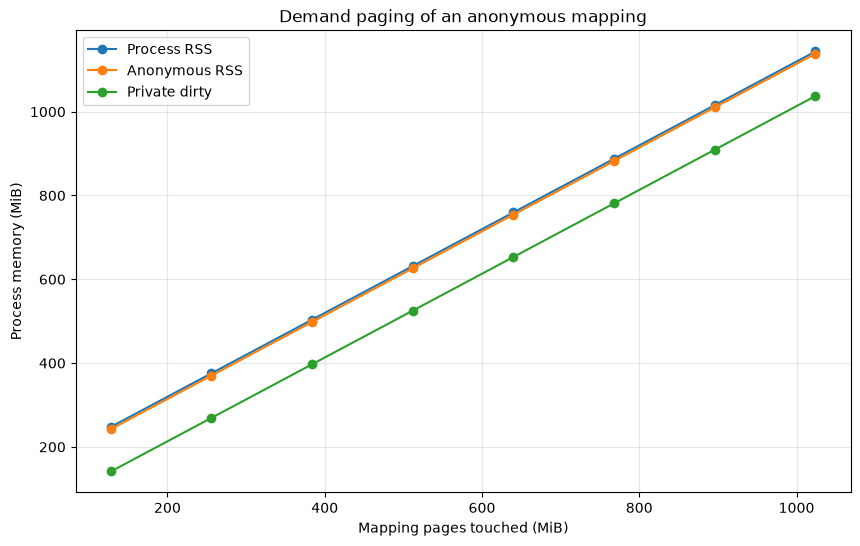

In [ ]:
import matplotlib.pyplot as plt


touch_rows = anonymous_results[
    anonymous_results["stage"].str.startswith("touched")
].copy()

touch_rows["touched_mib"] = touch_rows["stage"].str.extract(r"(\d+)")[0].astype(float)

figure, axis = plt.subplots(figsize=(10, 6))

axis.plot(
    touch_rows["touched_mib"],
    touch_rows["process_VmRSS_mib"],
    marker="o",
    label="Process RSS",
)

axis.plot(
    touch_rows["touched_mib"],
    touch_rows["process_RssAnon_mib"],
    marker="o",
    label="Anonymous RSS",
)

axis.plot(
    touch_rows["touched_mib"],
    touch_rows["smaps_Private_Dirty_mib"],
    marker="o",
    label="Private dirty",
)

axis.set_xlabel("Mapping pages touched (MiB)")
axis.set_ylabel("Process memory (MiB)")
axis.set_title("Demand paging of an anonymous mapping")
axis.grid(True, alpha=0.3)
axis.legend()

plt.show()

In [17]:
parent_connection.send({"action": "release"})

release_message = parent_connection.recv()
assert release_message["event"] == "released"

time.sleep(0.5)

anonymous_snapshots.append(
    collect_memory_snapshot(
        child_pid,
        "released",
    )
)

anonymous_results = pd.DataFrame(anonymous_snapshots)

anonymous_results.tail(3)[
    [
        "stage",
        "process_VmSize_mib",
        "process_VmRSS_mib",
        "process_RssAnon_mib",
        "smaps_Anonymous_mib",
        "smaps_Private_Dirty_mib",
        "system_MemAvailable_mib",
    ]
]

,stage,process_VmSize_mib,process_VmRSS_mib,process_RssAnon_mib,smaps_Anonymous_mib,smaps_Private_Dirty_mib,system_MemAvailable_mib
8,touched 896 MiB,3658.421875,1015.664062,1010.324219,1010.324219,909.273438,115689.679688
9,touched 1024 MiB,3658.421875,1143.664062,1138.324219,1138.324219,1037.285156,115563.679688
10,released,2634.421875,119.664062,114.324219,114.324219,26.371094,116734.769531


In [18]:
parent_connection.send({"action": "exit"})

exit_message = parent_connection.recv()
assert exit_message["event"] == "exiting"

parent_connection.close()

memory_process.join(timeout=5)

if memory_process.is_alive():
    memory_process.terminate()
    memory_process.join(timeout=5)

print(f"Child exit code: {memory_process.exitcode}")

Child exit code: 0


In [ ]:
import os
from pathlib import Path


FILE_MAPPING_SIZE = 512 * 1024**2
FILE_TOUCH_INCREMENT = 64 * 1024**2
FILE_WRITE_CHUNK_SIZE = 8 * 1024**2

file_experiment_directory = repository_root / ".tmp" / "linux-memory"
file_experiment_directory.mkdir(
    parents=True,
    exist_ok=True,
)

mapped_file_path = file_experiment_directory / "page-cache-experiment.bin"

write_chunk = bytes(index % 251 for index in range(FILE_WRITE_CHUNK_SIZE))

with mapped_file_path.open("wb", buffering=0) as file_handle:
    remaining = FILE_MAPPING_SIZE

    while remaining > 0:
        chunk = write_chunk[: min(len(write_chunk), remaining)]
        file_handle.write(chunk)
        remaining -= len(chunk)

    os.fsync(file_handle.fileno())

print(f"File: {mapped_file_path}")
print(f"Size: {mapped_file_path.stat().st_size / 1024**2:.0f} MiB")

File: /home/coert/workspace/dgx-spark-lab/.tmp/linux-memory/page-cache-experiment.bin
Size: 512 MiB


In [ ]:
def request_file_cache_eviction(path: Path) -> bool:
    """Ask Linux to discard cached pages belonging to one file."""
    if not hasattr(os, "posix_fadvise"):
        return False

    with path.open("rb", buffering=0) as file_handle:
        os.posix_fadvise(
            file_handle.fileno(),
            0,
            0,
            os.POSIX_FADV_DONTNEED,
        )

    return True


eviction_requested = request_file_cache_eviction(mapped_file_path)

print(f"POSIX_FADV_DONTNEED requested: {eviction_requested}")

time.sleep(0.5)

POSIX_FADV_DONTNEED requested: True


In [21]:
def file_memory_worker(
    connection: Connection,
    file_path: str,
    mapping_size: int,
    page_size: int,
) -> None:
    """Map and progressively read a regular file."""
    file_handle = None
    mapping: mmap.mmap | None = None
    touched_bytes = 0
    checksum = 0

    try:
        connection.send(
            {
                "event": "ready",
                "pid": os.getpid(),
                "page_size": page_size,
            }
        )

        while True:
            command = connection.recv()
            action = command["action"]

            if action == "map":
                if mapping is not None:
                    raise RuntimeError("File is already mapped")

                file_handle = open(
                    file_path,
                    "rb",
                    buffering=0,
                )

                mapping = mmap.mmap(
                    file_handle.fileno(),
                    mapping_size,
                    flags=mmap.MAP_SHARED,
                    prot=mmap.PROT_READ,
                )

                touched_bytes = 0
                checksum = 0

                connection.send(
                    {
                        "event": "mapped",
                        "touched_bytes": touched_bytes,
                    }
                )

            elif action == "read":
                if mapping is None:
                    raise RuntimeError("No file mapping exists")

                requested_bytes = int(command["bytes"])
                new_limit = min(
                    mapping_size,
                    touched_bytes + requested_bytes,
                )

                for offset in range(
                    touched_bytes,
                    new_limit,
                    page_size,
                ):
                    checksum += mapping[offset]

                touched_bytes = new_limit

                connection.send(
                    {
                        "event": "read",
                        "touched_bytes": touched_bytes,
                        "checksum": checksum,
                    }
                )

            elif action == "unmap":
                if mapping is not None:
                    mapping.close()
                    mapping = None

                if file_handle is not None:
                    file_handle.close()
                    file_handle = None

                touched_bytes = 0

                connection.send(
                    {
                        "event": "unmapped",
                        "checksum": checksum,
                    }
                )

            elif action == "exit":
                if mapping is not None:
                    mapping.close()

                if file_handle is not None:
                    file_handle.close()

                connection.send(
                    {
                        "event": "exiting",
                        "checksum": checksum,
                    }
                )
                break

            else:
                raise ValueError(f"Unknown action: {action!r}")

    finally:
        connection.close()

In [ ]:
file_parent_connection, file_child_connection = memory_context.Pipe()

file_memory_process = memory_context.Process(
    target=file_memory_worker,
    args=(
        file_child_connection,
        str(mapped_file_path),
        FILE_MAPPING_SIZE,
        PAGE_SIZE,
    ),
)

file_memory_process.start()
file_child_connection.close()

try:
    file_ready_message = file_parent_connection.recv()
except EOFError as error:
    file_memory_process.join(timeout=1)

    raise RuntimeError(
        "The file-memory child exited before initialization. "
        f"Exit code: {file_memory_process.exitcode}"
    ) from error

assert file_ready_message["event"] == "ready"

file_child_pid = int(file_ready_message["pid"])

print(f"Child PID: {file_child_pid}")
print(f"File size: {FILE_MAPPING_SIZE / 1024**2:.0f} MiB")

file_snapshots: list[dict[str, object]] = []

file_snapshots.append(
    collect_memory_snapshot(
        file_child_pid,
        "baseline",
    )
)

Child PID: 196180
File size: 512 MiB


In [23]:
file_parent_connection.send({"action": "map"})

mapped_message = file_parent_connection.recv()
assert mapped_message["event"] == "mapped"

time.sleep(0.2)

file_snapshots.append(
    collect_memory_snapshot(
        file_child_pid,
        "mapped 512 MiB",
    )
)

pd.DataFrame(file_snapshots)[
    [
        "stage",
        "process_VmSize_mib",
        "process_VmRSS_mib",
        "process_RssAnon_mib",
        "process_RssFile_mib",
        "smaps_Private_Clean_mib",
        "smaps_Private_Dirty_mib",
        "system_Cached_mib",
        "system_MemAvailable_mib",
    ]
]

,stage,process_VmSize_mib,process_VmRSS_mib,process_RssAnon_mib,process_RssFile_mib,smaps_Private_Clean_mib,smaps_Private_Dirty_mib,system_Cached_mib,system_MemAvailable_mib
0,baseline,2750.289062,160.363281,153.480469,6.882812,0.0,4.695312,16144.132812,116447.414062
1,mapped 512 MiB,3262.289062,160.488281,153.480469,7.007812,0.0,8.437500,16144.140625,116491.742188


In [24]:
for expected_total in range(
    FILE_TOUCH_INCREMENT,
    FILE_MAPPING_SIZE + FILE_TOUCH_INCREMENT,
    FILE_TOUCH_INCREMENT,
):
    file_parent_connection.send(
        {
            "action": "read",
            "bytes": FILE_TOUCH_INCREMENT,
        }
    )

    read_message = file_parent_connection.recv()
    assert read_message["event"] == "read"

    actual_read = int(read_message["touched_bytes"])

    time.sleep(0.2)

    file_snapshots.append(
        collect_memory_snapshot(
            file_child_pid,
            f"read {actual_read / 1024**2:.0f} MiB",
        )
    )

print(f"Final checksum: {read_message['checksum']}")

Final checksum: 16378944


In [25]:
file_results = pd.DataFrame(file_snapshots)

file_results[
    [
        "stage",
        "process_VmSize_mib",
        "process_VmRSS_mib",
        "process_RssAnon_mib",
        "process_RssFile_mib",
        "smaps_Private_Clean_mib",
        "smaps_Shared_Clean_mib",
        "smaps_Private_Dirty_mib",
        "system_Cached_mib",
        "system_MemAvailable_mib",
    ]
]

,stage,process_VmSize_mib,process_VmRSS_mib,process_RssAnon_mib,process_RssFile_mib,smaps_Private_Clean_mib,smaps_Shared_Clean_mib,smaps_Private_Dirty_mib,system_Cached_mib,system_MemAvailable_mib
0,baseline,2750.289062,160.363281,153.480469,6.882812,0.0,6.882812,4.695312,16144.132812,116447.414062
1,mapped 512 MiB,3262.289062,160.488281,153.480469,7.007812,0.0,7.007812,8.437500,16144.140625,116491.742188
2,read 64 MiB,3262.289062,224.550781,153.480469,71.070312,64.0,7.070312,13.125000,16208.410156,116672.441406
3,read 128 MiB,3262.289062,288.550781,153.480469,135.070312,128.0,7.070312,13.128906,16272.410156,116672.441406
4,read 192 MiB,3262.289062,352.550781,153.480469,199.070312,192.0,7.070312,13.128906,16336.410156,116672.441406
5,read 256 MiB,3262.289062,416.550781,153.480469,263.070312,256.0,7.070312,13.128906,16400.410156,116672.441406
6,read 320 MiB,3262.289062,480.550781,153.480469,327.070312,320.0,7.070312,13.128906,16464.410156,116672.441406
7,read 384 MiB,3262.289062,544.550781,153.480469,391.070312,384.0,7.070312,13.128906,16528.410156,116672.195312
8,read 448 MiB,3262.289062,608.550781,153.480469,455.070312,448.0,7.070312,13.128906,16592.410156,116672.195312
9,read 512 MiB,3262.289062,672.550781,153.480469,519.070312,512.0,7.070312,13.132812,16656.285156,116671.949219


In [ ]:
file_baseline = file_results.iloc[0]

file_deltas = file_results.copy()

FILE_DELTA_FIELDS = [
    "process_VmSize_mib",
    "process_VmRSS_mib",
    "process_RssAnon_mib",
    "process_RssFile_mib",
    "smaps_Private_Clean_mib",
    "smaps_Shared_Clean_mib",
    "smaps_Private_Dirty_mib",
    "system_Cached_mib",
    "system_MemAvailable_mib",
]

for field in FILE_DELTA_FIELDS:
    file_deltas[f"{field}_delta"] = file_deltas[field] - file_baseline[field]

file_deltas[
    [
        "stage",
        "process_VmSize_mib_delta",
        "process_VmRSS_mib_delta",
        "process_RssAnon_mib_delta",
        "process_RssFile_mib_delta",
        "smaps_Private_Clean_mib_delta",
        "smaps_Shared_Clean_mib_delta",
        "smaps_Private_Dirty_mib_delta",
        "system_Cached_mib_delta",
        "system_MemAvailable_mib_delta",
    ]
]

,stage,process_VmSize_mib_delta,process_VmRSS_mib_delta,process_RssAnon_mib_delta,process_RssFile_mib_delta,smaps_Private_Clean_mib_delta,smaps_Shared_Clean_mib_delta,smaps_Private_Dirty_mib_delta,system_Cached_mib_delta,system_MemAvailable_mib_delta
0,baseline,0.0,0.0000,0.0,0.0000,0.0,0.0000,0.000000,0.000000,0.000000
1,mapped 512 MiB,512.0,0.1250,0.0,0.1250,0.0,0.1250,3.742188,0.007812,44.328125
2,read 64 MiB,512.0,64.1875,0.0,64.1875,64.0,0.1875,8.429688,64.277344,225.027344
3,read 128 MiB,512.0,128.1875,0.0,128.1875,128.0,0.1875,8.433594,128.277344,225.027344
4,read 192 MiB,512.0,192.1875,0.0,192.1875,192.0,0.1875,8.433594,192.277344,225.027344
5,read 256 MiB,512.0,256.1875,0.0,256.1875,256.0,0.1875,8.433594,256.277344,225.027344
6,read 320 MiB,512.0,320.1875,0.0,320.1875,320.0,0.1875,8.433594,320.277344,225.027344
7,read 384 MiB,512.0,384.1875,0.0,384.1875,384.0,0.1875,8.433594,384.277344,224.781250
8,read 448 MiB,512.0,448.1875,0.0,448.1875,448.0,0.1875,8.433594,448.277344,224.781250
9,read 512 MiB,512.0,512.1875,0.0,512.1875,512.0,0.1875,8.437500,512.152344,224.535156


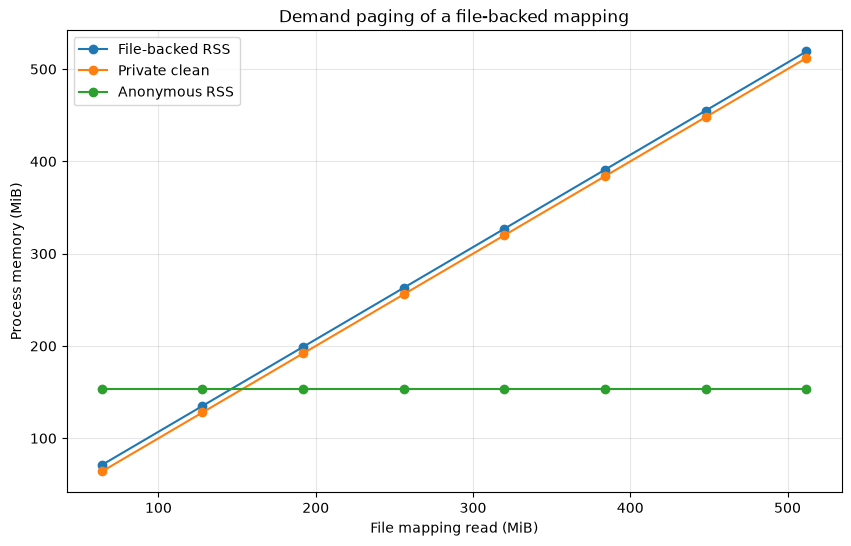

In [ ]:
file_read_rows = file_results[file_results["stage"].str.startswith("read")].copy()

file_read_rows["read_mib"] = (
    file_read_rows["stage"].str.extract(r"(\d+)")[0].astype(float)
)

figure, axis = plt.subplots(figsize=(10, 6))

axis.plot(
    file_read_rows["read_mib"],
    file_read_rows["process_RssFile_mib"],
    marker="o",
    label="File-backed RSS",
)

axis.plot(
    file_read_rows["read_mib"],
    file_read_rows["smaps_Private_Clean_mib"],
    marker="o",
    label="Private clean",
)

axis.plot(
    file_read_rows["read_mib"],
    file_read_rows["process_RssAnon_mib"],
    marker="o",
    label="Anonymous RSS",
)

axis.set_xlabel("File mapping read (MiB)")
axis.set_ylabel("Process memory (MiB)")
axis.set_title("Demand paging of a file-backed mapping")
axis.grid(True, alpha=0.3)
axis.legend()

plt.show()

In [28]:
file_parent_connection.send({"action": "unmap"})

unmapped_message = file_parent_connection.recv()
assert unmapped_message["event"] == "unmapped"

time.sleep(0.5)

file_snapshots.append(
    collect_memory_snapshot(
        file_child_pid,
        "unmapped",
    )
)

file_results = pd.DataFrame(file_snapshots)

file_results.tail(3)[
    [
        "stage",
        "process_VmSize_mib",
        "process_VmRSS_mib",
        "process_RssFile_mib",
        "smaps_Private_Clean_mib",
        "system_Cached_mib",
        "system_MemAvailable_mib",
    ]
]

,stage,process_VmSize_mib,process_VmRSS_mib,process_RssFile_mib,smaps_Private_Clean_mib,system_Cached_mib,system_MemAvailable_mib
8,read 448 MiB,3262.289062,608.550781,455.070312,448.0,16592.410156,116672.195312
9,read 512 MiB,3262.289062,672.550781,519.070312,512.0,16656.285156,116671.949219
10,unmapped,2750.289062,160.550781,7.070312,0.0,16656.316406,116625.457031


In [29]:
file_parent_connection.send({"action": "exit"})

file_exit_message = file_parent_connection.recv()
assert file_exit_message["event"] == "exiting"

file_parent_connection.close()

file_memory_process.join(timeout=5)

if file_memory_process.is_alive():
    file_memory_process.terminate()
    file_memory_process.join(timeout=5)

print(f"Child exit code: {file_memory_process.exitcode}")

Child exit code: 0


In [ ]:
cached_before_eviction = read_key_value_file(Path("/proc/meminfo"))["Cached"]

eviction_requested = request_file_cache_eviction(mapped_file_path)

time.sleep(1.0)

cached_after_eviction = read_key_value_file(Path("/proc/meminfo"))["Cached"]

print(f"Eviction requested: {eviction_requested}")
print(f"Cached before eviction: {cached_before_eviction / 1024**2:.1f} MiB")
print(f"Cached after eviction:  {cached_after_eviction / 1024**2:.1f} MiB")
print(
    "Difference:             "
    f"{(cached_after_eviction - cached_before_eviction) / 1024**2:.1f} MiB"
)

Eviction requested: True
Cached before eviction: 16656.3 MiB
Cached after eviction:  16144.3 MiB
Difference:             -512.0 MiB


In [31]:
mapped_file_path.unlink(missing_ok=True)

try:
    file_experiment_directory.rmdir()
    file_experiment_directory.parent.rmdir()
except OSError:
    pass

print(f"File still exists: {mapped_file_path.exists()}")

File still exists: False


## Observations

Reserving a 1 GiB anonymous mapping increased the child process's `VmSize` by exactly 1024 MiB, from 2634.42 MiB to 3658.42 MiB. Its RSS increased by only 0.19 MiB, while `RssAnon` and `smaps` anonymous memory did not increase. Reserving virtual address space therefore did not make the mapped pages physically resident.

Touching one byte in each 4 KiB page caused RSS and anonymous RSS to grow linearly. Each additional 128 MiB touched produced an approximately 128 MiB increase in both counters. After all 1 GiB had been touched, RSS had increased by 1024.19 MiB and anonymous RSS by exactly 1024 MiB.

The system page-table counter increased by approximately 2.1 MiB while the mapping was resident. This closely matches the roughly 2 MiB of page-table entries required to describe 262,144 individual 4 KiB pages.

Closing the mapping returned `VmSize`, RSS, and anonymous RSS to approximately their baseline values. System-wide `MemAvailable` also recovered, although its values were noisier because they included concurrent activity from the rest of the machine.


## Explanation

Linux separates virtual address-space reservation from physical page allocation. Creating the anonymous mapping established a valid one-GiB virtual address range, which appeared immediately in `VmSize`. The kernel did not initially allocate physical backing pages, so process RSS and anonymous RSS remained unchanged.

The first write to each page generated a page fault. Linux responded by allocating a physical page, installing the corresponding page-table entry, and marking the page private and dirty. Touching one byte per page was sufficient to make the entire page resident, which explains why RSS increased in exact 128 MiB steps even though only one byte was explicitly written in each 4 KiB page.

The process-local counters tracked the experiment precisely. System-wide counters such as `MemAvailable` and `AnonPages` showed the same general trend but also reflected unrelated process activity, kernel memory management, and cache reclamation.

Because the notebook used the Linux `fork` start method, the child initially shared many inherited Python pages with the notebook process through copy-on-write. Normal child-process execution dirtied some of those inherited pages, explaining the small additional increase in `Private_Dirty` that remained after the experimental mapping had been released.


## Connection to LLMs

Model loading and inference depend on accurate interpretation of host and unified-memory pressure.

## Further Exploration

TODO: Compare anonymous allocation, memory mapping, and filesystem cache behavior.